In [2]:
import argparse
import os
import re
import numpy as np

import statistics
import msprime
from IPython.display import SVG, display
import tsinfer
import scipy
import math
import numpy
import tskit
import io
import builtins
import sys
from tqdm.notebook import tqdm
from tskit import MISSING_DATA
import pickle
import random
import matplotlib.pyplot as plt
import cvxopt as opt
from cvxopt import matrix, spmatrix, sparse
from cvxopt.solvers import qp, options
from cvxopt import blas
from cvxopt import spdiag
import statsmodels
from statsmodels.nonparametric.kernel_regression import KernelReg
from scipy.signal import savgol_filter
import time
import bisect


def find_s(elem, sorted_list):
    'Locate the leftmost value exactly equal to x'
    i = bisect.bisect_left(sorted_list, elem)
    if i != len(sorted_list) and sorted_list[i] == elem:
        return i


def find_s_se(elem, sorted_list):
    'Locate the leftmost value smaller or equal to x'
    i = bisect.bisect_right(sorted_list, elem)
    if i != 0:
        return i-1
    else:
        print("error")


def find_s_s(elem, sorted_list):
    'Locate the leftmost value smaller or equal to x'
    i = bisect.bisect_left(sorted_list, elem)
    if i != 0:
        return i
    else:
        return 0

    
file = open("recombination_map_chr21.dat","rb")
rmap = pickle.load(file)
file.close

sam=tsinfer.load("tgp_chr21.samples")

FINlist = []
for i in range(len(sam.individuals_population)):
    if sam.individuals_population[i]==7:
        FINlist.append(i)
newdata = sam.subset(individuals=FINlist)

        
seq_len = 48129897
sam_size = 99
r = rmap
mu = 1.25*10**(-8)
# gene_conver = 10**(-8)
# track_len = 100
# epsilon = 0.0001
totaliter=1

simtime = 100
priormu = [1.0*10**(-8), 2.0*10**(-8)]
# prioreps = [0, 0.0002]
# accept_threshold = [1000,400]




genpoint = [0*5/5.2,400*5/5.2,800*5/5.2,1200*5/5.2,1600*5/5.2,2000*5/5.2,2400*5/5.2,2800*5/5.2,\
            3200*5/5.2,3600*5/5.2,4000*5/5.2,8000*5/5.2,12000*5/5.2,16000*5/5.2]
inipopsize =[20000*5/5.2, 10000*5/5.2, 5000*5/5.2, 2600*5/5.2,  2600*5/5.2, 2800*5/5.2, 3600*5/5.2,4400*5/5.2,\
             6000*5/5.2,8000*5/5.2,10000*5/5.2,26800*5/5.2,26800*5/5.2,22000*5/5.2]
genuse = []
inipuse = []
gruse = []
for i in range(len(genpoint)-1):
    addplist = []
    for j in range(10):
        addplist.append(genpoint[i] + (genpoint[i+1]-genpoint[i])/10*j)
    genuse = genuse + addplist
for i in range(len(inipopsize)-1):
    addplist = []
    for j in range(10):
        addplist.append(inipopsize[i] + (inipopsize[i+1]-inipopsize[i])/10*j)
    inipuse = inipuse + addplist
genuse.append(genpoint[len(genpoint)-1])
inipuse.append(inipopsize[len(inipopsize)-1])
for i in range(len(genuse)-1):
    gruse.append( numpy.log( inipuse[i]/inipuse[i+1] )/(genuse[i+1] - genuse[i])  )
gruse.append(0.000003)

demo_model = msprime.Demography.isolated_model([inipuse[0]], growth_rate=[gruse[0]])
for i in range(1,len(genuse)):
    demo_model.add_population_parameters_change(genuse[i],  initial_size=inipuse[i], growth_rate=gruse[i], population=None)








muhatlist = []
# epshatlist = []
muacceptlist = []
# epsacceptlist = []
for iter in range(totaliter):
    
#     ts = msprime.sim_ancestry(
#         samples=sam_size,
#         recombination_rate= r, 
#         sequence_length= seq_len,
# #         population_size = pop_size,
#         gene_conversion_rate = gene_conver ,
#         gene_conversion_tract_length = track_len,
#         #random_seed =seed,
#         #discrete_genome=False
#         demography = demo_model
#         )
#     # Visualise the simulated ancestral history.
#     #SVG(ts.draw_svg())

#     #ts.num_trees

#     mts = msprime.sim_mutations(ts, rate = mu,
#                                 #discrete_genome=False,
#                                 #random_seed=seed
#                               )

#     sample_data = tsinfer.SampleData.from_tree_sequence(mts, use_sites_time=None, use_individuals_time=None)
    
    print("done1")
        
##########################################################################################

#     newdata = tsinfer.SampleData()

#     gtypetable1 = sample_data.sites_genotypes 
#     gtypetable = gtypetable1[0:len(gtypetable1)]
#     gtypetable = gtypetable.astype("int")

#     alletable1 = sample_data.sites_alleles 
#     alletable = alletable1[0:len(alletable1)]

#     posittable1 = sample_data.sites_position 
#     posittable = posittable1[0:len(posittable1)]

#     for i in range(len(sample_data.sites_position) - 1):
#         alle = alletable[i]
#         posit = posittable[i]
#         posit1 = posittable[i+1]
#         gtype = gtypetable[i].tolist()
#         newdata.add_site(position = posit, genotypes = gtype,alleles = alle)

#         numerror = numpy.random.poisson( (posit1-posit)*2*sam_size*epsilon )
#         locerror = numpy.sort(numpy.floor(numpy.random.uniform(posit, posit1-0.000000001,numerror) )  ) .tolist()

#         curloc = posit
#         for j in range(len(locerror)):
#             if locerror[j] > curloc:
#                 curloc = locerror[j]
#                 gtype = numpy.zeros(2*sam_size  )
#                 gtype[int( numpy.random.uniform(0,2*sam_size-0.00001)   ) ] = 1
#                 gtype = gtype.astype('int').tolist()


#                 newdata.add_site(position = curloc, genotypes = gtype,alleles = ['A','T'])

#     alle = alletable[-1]
#     posit = posittable[-1]
#     gtype = gtypetable[-1].tolist()
#     newdata.add_site(position = posit, genotypes = gtype,alleles = alle)


#     newdata.finalise()



################################################################################


    inferred_ts = tsinfer.infer(newdata,path_compression=False)
    
    print("done2")

#############################################################################

    mts = inferred_ts

###############################################################################
    msites = mts.tables.mutations.site
    sitepos = mts.tables.sites.position
    mpos = []
    for i in range(len(msites)):
        cursite = msites[i]
        mpos.append(sitepos[cursite])
    mpos = numpy.array(mpos)
    mnodes = mts.tables.mutations.node
    ec = mts.tables.edges.child
    ep = mts.tables.edges.parent
    el = mts.tables.edges.left
    er = mts.tables.edges.right


    leftmost = min(el)
    rightmost = max(er)
    for i in range(len(el)):
        if el[i] == leftmost:
            el[i] = 0
        if er[i] == rightmost:
            er[i] = seq_len


    if len(mpos) == 0:
        mpos_sn = []
        mnodes_sn = []
    else:
        mnp_sn = numpy.transpose(sorted(numpy.transpose(numpy.array([mnodes,mpos])).tolist()))
        mnodes_sn = mnp_sn[0]
        mpos_sn = mnp_sn[1]

    eclrp_sc = numpy.transpose(sorted(numpy.transpose(numpy.array([ec,el,er,ep])).tolist()))
    ec_sc = eclrp_sc[0]
    el_sc = eclrp_sc[1]
    er_sc = eclrp_sc[2]
    ep_sc = eclrp_sc[3]
    enm_sc = [[] for i in range(len(ec_sc))]

    curedge = 0
    for i in range(len(mnodes_sn)):
        curnodemu = mnodes_sn[i] 
        cursitemu = mpos_sn[i]
        for j in range(curedge,len(ec_sc)):
            if curnodemu == ec_sc[j]:

                if er_sc[j] > cursitemu and el_sc[j] <= cursitemu:

                    enm_sc[j].append(cursitemu)  

                    curedge = j
                    break
                if el_sc[j] > cursitemu:
                    curedge = j
                    break

            if ec_sc[j] > mnodes_sn[i] or j == len(ec_sc)-1:
                #print("missing mutations")
                curedge = j
                break


 

    ###########################################################################
    ###########################################################################
    ##########################################################################

    clocate = []
    curc = -1
    for i in range(len(ec_sc)):
        while ec_sc[i] != curc:
            curc=curc+1
            clocate.append(i)
    clocate.append(len(ec_sc))




    abdlist = []

    for i in range(0,2*sam_size-1):
        for j in range(i+1,i+2):
            canabd = []
            curleft = 0
            curright =seq_len
            #start = 0
            while curleft != seq_len:
                curp1 = i
                curp2 = j 
                curmed = []
                while curp1 != curp2:
                    if curp1 < curp2:
                        begin1 = clocate[curp1]
                        end = clocate[curp1+1]
                        s_range = el_sc[begin1:end]
                        begin2 = find_s_se(curleft,s_range)
                        for k in range(begin1+begin2,end):
                            if el_sc[k]<=curleft and er_sc[k] > curleft:
                                curp1 = int(ep_sc[k])
                                curoldr = curright
                                curright = min(er_sc[k],curright)

                                curmed.append(k)

                                break

                    else:
                        begin1 = clocate[curp2]
                        end = clocate[curp2+1]
                        s_range = el_sc[begin1:end]
                        begin2 = find_s_se(curleft,s_range)
                        for k in range(begin1+begin2,end):
                            if el_sc[k]<=curleft and er_sc[k] > curleft:
                                curp2 = int(ep_sc[k])
                                curoldr = curright
                                curright = min(er_sc[k],curright) 

                                curmed.append(k)

                                break

                canmution = []
                for k in range(len(curmed)):
                    edgemu = enm_sc[curmed[k]]
                    startt = find_s_s(curleft,edgemu)
                    endd = find_s_s(curright,edgemu)                    
                    canmution = canmution + edgemu[startt:endd] 

                canabd.append([i,j,curleft,curright,curp1,canmution])
                curleft = curright
                curright = seq_len





            if len(canabd)==1:
                abdlist = abdlist + canabd
            else:
                curabd = [canabd[0][0],canabd[0][1],canabd[0][2],canabd[0][3],canabd[0][4],canabd[0][5]]
                for k in range(1,len(canabd)):
                    if canabd[k][4] != canabd[k-1][4]:
                        abdlist.append(curabd)
                        curabd = [canabd[k][0],canabd[k][1],canabd[k][2],canabd[k][3],canabd[k][4],canabd[k][5]]
                    else:
                        curabd[3] = canabd[k][3]
                        curabd[5] = curabd[5] + canabd[k][5]
                    if k == len(canabd)-1:
                        abdlist.append(curabd)
       
    
    
#         print("abdlist sample:",i)
        
        
        

    lllabd = len(abdlist)
    print(lllabd)
###########################################################################
###########################################################################
##########################################################################

#     #find time
#     #nt = mts.tables.nodes.time
#     nt = ts.tables.nodes.time
#     for i in range(len(abdlist)):
#         parent = int(abdlist[i][4])
#         abdlist[i].append(-1)

#         # add typing error
#         abdlist[i].append( len(abdlist[i][5])  )



###########################################################################
###########################################################################
##########################################################################

    
    abduse = abdlist



    tolnummu = 0
    for i in range(len(abduse)):
        tolnummu = tolnummu+len(abduse[i][5])

    muloclist = np.zeros(tolnummu)
    indd = 0
    for i in range(len(abduse)):
        abdc = abduse[i]
        lee = len(abdc[5])
        muloclist[indd:(indd+lee)] = abdc[5]
        indd = indd+lee

    smulist = numpy.sort(muloclist)
    count2 = 0
    curloc = -1
    curcount = 1
    for i in range(len(smulist)):
        if smulist[i] == curloc:
            curcount = curcount+1
        else:
            if curcount ==2:
                count2 = count2+1
            curcount = 1
            curloc = smulist[i]

#     summary_sta1_inf = (len(smulist) - 2*count2)/len(abduse)        
#     summary_sta2_inf = (2*count2) / len(abduse)  


    summary_sta1_inf = (len(smulist) - 2*count2)      
    summary_sta2_inf = (2*count2) 




##########################################################################
    
    muaccept = []
#     epsaccept = []
    summary_sta1_simlist=[]
    summary_sta2_simlist=[]
    stime = time.time()

    for run in range(simtime):
        
        musim = numpy.random.uniform(priormu[0],priormu[1])

        
#         if run == 0:
#             musim = 1.32*10**(-8)
#         if run == 1:
#             musim = 1.32*10**(-8)
#         if run == 2:
#             musim = 1.4*10**(-8)
#         if run == 3:
#             musim = 1.4*10**(-8)            
#         if run == 4:
#             musim = 1.5*10**(-8)            
#         if run == 5:
#             musim = 1.5*10**(-8)
            
            
#         epssim = numpy.random.uniform(prioreps[0],prioreps[1])
        print("done1")
 
        ts = msprime.sim_ancestry(
            samples=sam_size,
            recombination_rate= r, 
            sequence_length= seq_len,
            record_provenance=False,
#             population_size = pop_size,
#             gene_conversion_rate = gene_conver ,
#             gene_conversion_tract_length = track_len,
            #random_seed =seed,
            #discrete_genome=False
            demography = demo_model
            )
        # Visualise the simulated ancestral history.
        #SVG(ts.draw_svg())

        #ts.num_trees
        
        print("done gene")

        mts = msprime.sim_mutations(ts, rate = musim,
                                    #discrete_genome=False,
                                    #random_seed=seed
                                  )

        print("done mu")

        sample_data = tsinfer.SampleData.from_tree_sequence(mts, use_sites_time=None, use_individuals_time=None)


        print("done sam")
##########################################################################################

#         newdata = tsinfer.SampleData()

#         gtypetable1 = sample_data.sites_genotypes 
#         gtypetable = gtypetable1[0:len(gtypetable1)]
#         gtypetable = gtypetable.astype("int")

#         alletable1 = sample_data.sites_alleles 
#         alletable = alletable1[0:len(alletable1)]

#         posittable1 = sample_data.sites_position 
#         posittable = posittable1[0:len(posittable1)]

#         for i in range(len(sample_data.sites_position) - 1):
#             alle = alletable[i]
#             posit = posittable[i]
#             posit1 = posittable[i+1]
#             gtype = gtypetable[i].tolist()
#             newdata.add_site(position = posit, genotypes = gtype,alleles = alle)

#             numerror = numpy.random.poisson( (posit1-posit)*2*sam_size*epssim )
#             locerror = numpy.sort(numpy.floor(numpy.random.uniform(posit, posit1-0.000000001,numerror) )  ) .tolist()

#             curloc = posit
#             for j in range(len(locerror)):
#                 if locerror[j] > curloc:
#                     curloc = locerror[j]
#                     gtype = numpy.zeros(2*sam_size  )
#                     gtype[int( numpy.random.uniform(0,2*sam_size-0.00001)   ) ] = 1
#                     gtype = gtype.astype('int').tolist()


#                     newdata.add_site(position = curloc, genotypes = gtype,alleles = ['A','T'])

#         alle = alletable[-1]
#         posit = posittable[-1]
#         gtype = gtypetable[-1].tolist()
#         newdata.add_site(position = posit, genotypes = gtype,alleles = alle)


#         newdata.finalise()

        
################################################################################


        inferred_ts = tsinfer.infer(sample_data,path_compression=False)

        print("iter",run,"done2")
        
        
#############################################################################

        mts = inferred_ts

###############################################################################

        msites = mts.tables.mutations.site
        sitepos = mts.tables.sites.position
        mpos = []
        for i in range(len(msites)):
            cursite = msites[i]
            mpos.append(sitepos[cursite])
        mpos = numpy.array(mpos)
        mnodes = mts.tables.mutations.node
        ec = mts.tables.edges.child
        ep = mts.tables.edges.parent
        el = mts.tables.edges.left
        er = mts.tables.edges.right


        leftmost = min(el)
        rightmost = max(er)
        for i in range(len(el)):
            if el[i] == leftmost:
                el[i] = 0
            if er[i] == rightmost:
                er[i] = seq_len


        if len(mpos) == 0:
            mpos_sn = []
            mnodes_sn = []
        else:
            mnp_sn = numpy.transpose(sorted(numpy.transpose(numpy.array([mnodes,mpos])).tolist()))
            mnodes_sn = mnp_sn[0]
            mpos_sn = mnp_sn[1]

        eclrp_sc = numpy.transpose(sorted(numpy.transpose(numpy.array([ec,el,er,ep])).tolist()))
        ec_sc = eclrp_sc[0]
        el_sc = eclrp_sc[1]
        er_sc = eclrp_sc[2]
        ep_sc = eclrp_sc[3]
        enm_sc = [[] for i in range(len(ec_sc))]

        curedge = 0
        for i in range(len(mnodes_sn)):
            curnodemu = mnodes_sn[i] 
            cursitemu = mpos_sn[i]
            for j in range(curedge,len(ec_sc)):
                if curnodemu == ec_sc[j]:

                    if er_sc[j] > cursitemu and el_sc[j] <= cursitemu:

                        enm_sc[j].append(cursitemu)  

                        curedge = j
                        break
                    if el_sc[j] > cursitemu:
                        curedge = j
                        break

                if ec_sc[j] > mnodes_sn[i] or j == len(ec_sc)-1:
                    #print("missing mutations")
                    curedge = j
                    break




        ###########################################################################
        ###########################################################################
        ##########################################################################

        clocate = []
        curc = -1
        for i in range(len(ec_sc)):
            while ec_sc[i] != curc:
                curc=curc+1
                clocate.append(i)
        clocate.append(len(ec_sc))




        abdlist = []

        for i in range(0,2*sam_size-1):
            for j in range(i+1,i+2):
                canabd = []
                curleft = 0
                curright =seq_len
                #start = 0
                while curleft != seq_len:
                    curp1 = i
                    curp2 = j 
                    curmed = []
                    while curp1 != curp2:
                        if curp1 < curp2:
                            begin1 = clocate[curp1]
                            end = clocate[curp1+1]
                            s_range = el_sc[begin1:end]
                            begin2 = find_s_se(curleft,s_range)
                            for k in range(begin1+begin2,end):
                                if el_sc[k]<=curleft and er_sc[k] > curleft:
                                    curp1 = int(ep_sc[k])
                                    curoldr = curright
                                    curright = min(er_sc[k],curright)

                                    curmed.append(k)

                                    break

                        else:
                            begin1 = clocate[curp2]
                            end = clocate[curp2+1]
                            s_range = el_sc[begin1:end]
                            begin2 = find_s_se(curleft,s_range)
                            for k in range(begin1+begin2,end):
                                if el_sc[k]<=curleft and er_sc[k] > curleft:
                                    curp2 = int(ep_sc[k])
                                    curoldr = curright
                                    curright = min(er_sc[k],curright) 

                                    curmed.append(k)

                                    break

                    canmution = []
                    for k in range(len(curmed)):
                        edgemu = enm_sc[curmed[k]]
                        startt = find_s_s(curleft,edgemu)
                        endd = find_s_s(curright,edgemu)                    
                        canmution = canmution + edgemu[startt:endd] 

                    canabd.append([i,j,curleft,curright,curp1,canmution])
                    curleft = curright
                    curright = seq_len





                if len(canabd)==1:
                    abdlist = abdlist + canabd
                else:
                    curabd = [canabd[0][0],canabd[0][1],canabd[0][2],canabd[0][3],canabd[0][4],canabd[0][5]]
                    for k in range(1,len(canabd)):
                        if canabd[k][4] != canabd[k-1][4]:
                            abdlist.append(curabd)
                            curabd = [canabd[k][0],canabd[k][1],canabd[k][2],canabd[k][3],canabd[k][4],canabd[k][5]]
                        else:
                            curabd[3] = canabd[k][3]
                            curabd[5] = curabd[5] + canabd[k][5]
                        if k == len(canabd)-1:
                            abdlist.append(curabd)

#             print("iter:",run, "abdlist sample:",i)

    ###########################################################################
    ###########################################################################
    ##########################################################################

#         #find time
#         #nt = mts.tables.nodes.time
#         nt = ts.tables.nodes.time
#         for i in range(len(abdlist)):
#             parent = int(abdlist[i][4])
#             abdlist[i].append(-1)

#             # total typing error
#             abdlist[i].append( len(abdlist[i][5])  )
            



    ###########################################################################
    ###########################################################################
    ##########################################################################


        abduse = abdlist



        tolnummu = 0
        for i in range(len(abduse)):
            tolnummu = tolnummu+len(abduse[i][5])


        muloclist = np.zeros(tolnummu)
        indd = 0
        for i in range(len(abduse)):
            abdc = abduse[i]
            lee = len(abdc[5])
            muloclist[indd:(indd+lee)] = abdc[5]
            indd = indd+lee
            
        smulist = numpy.sort(muloclist)
        count2 = 0
        curloc = -1
        curcount = 1
        for i in range(len(smulist)):
            if smulist[i] == curloc:
                curcount = curcount+1
            else:
                if curcount ==2:
                    count2 = count2+1
                curcount = 1
                curloc = smulist[i]
        
#         summary_sta1_sim = (len(smulist) - 2*count2)/len(abduse)        
#         summary_sta2_sim = (2*count2) / len(abduse)

        summary_sta1_sim = (len(smulist) - 2*count2)        
        summary_sta2_sim = (2*count2)  

        summary_sta1_simlist.append(summary_sta1_sim)
        summary_sta2_simlist.append(summary_sta2_sim)
#         
#         if abs(summary_sta1_sim - summary_sta1_inf) < accept_threshold[0] and abs(summary_sta2_sim - summary_sta2_inf) < accept_threshold[1]:
        muaccept.append(musim)
#         epsaccept.append(epssim)

            
        etime = time.time()

            
        print("run",run,etime-stime,summary_sta1_simlist,summary_sta1_inf)
        
   
        
        
    muacceptlist = muacceptlist + muaccept
#     epsacceptlist= epsacceptlist + epsaccept
    
    
#     if len(muaccept)>0:    
#         muhatlist.append(statistics.mean(muaccept))
#     else:
#         muhatlist.append(None)    
        
#     if len(epsaccept)>0:    
#         epshatlist.append(statistics.mean(epsaccept))
#     else:
#         epshatlist.append(None)  
    
#     print(muhatlist)

byrun = 1
name1 = "chr21_arealmusimall_"+"run="+str(byrun) +"FIN_efibd.dat"
name3 = "chr21_arealsta1simall_"+"run="+str(byrun) +"FIN_efibd.dat"
name4 = "chr21_arealsta2simall_"+"run="+str(byrun) +"FIN_efibd.dat"
name5 = "chr21_arealsta1inf_"+"run="+str(byrun) +"FIN_efibd.dat"
name6 = "chr21_arealsta2inf_"+"run="+str(byrun) +"FIN_efibd.dat"
name7 = "chr21_arealabdlen_"+"run="+str(byrun) +"FIN_efibd.dat"

file = open(name1,"wb") 
pickle.dump(muacceptlist,file) 
file.close() 

file = open(name3,"wb") 
pickle.dump(summary_sta1_simlist,file) 
file.close() 

file = open(name4,"wb")  
pickle.dump(summary_sta2_simlist,file) 
file.close() 

file = open(name5,"wb") 
pickle.dump(summary_sta1_inf,file)
file.close()

file = open(name6,"wb") 
pickle.dump(summary_sta2_inf,file)
file.close()

file = open(name7,"wb") 
pickle.dump(lllabd,file)
file.close()

done1
done2
942117
done1
done gene
done mu
done sam
iter 0 done2
run 0 319.3960030078888 [5473331] 5215416
done1
done gene
done mu
done sam
iter 1 done2
run 1 621.9752504825592 [5473331, 5335236] 5215416
done1
done gene
done mu
done sam
iter 2 done2
run 2 941.1265904903412 [5473331, 5335236, 5305145] 5215416
done1
done gene
done mu
done sam
iter 3 done2
run 3 1270.7917926311493 [5473331, 5335236, 5305145, 6076566] 5215416
done1
done gene
done mu
done sam
iter 4 done2
run 4 1623.6033399105072 [5473331, 5335236, 5305145, 6076566, 6500858] 5215416
done1
done gene
done mu
done sam
iter 5 done2
run 5 1970.185082912445 [5473331, 5335236, 5305145, 6076566, 6500858, 5718707] 5215416


In [2]:
summary_sta1_simlist

[4304163, 4337991, 6603713, 5497563, 6818758, 7613783]

In [3]:
summary_sta1_inf

5215416

In [ ]:
demo_model = msprime.Demography.isolated_model([20000], growth_rate=[0])
demo_model.add_population_parameters_change(100,  initial_size=17500, growth_rate=0, population=None)
demo_model.add_population_parameters_change(200,  initial_size=15000, growth_rate=0, population=None)
demo_model.add_population_parameters_change(300,  initial_size=12500, growth_rate=-0, population=None)
demo_model.add_population_parameters_change(400,  initial_size=10000, growth_rate=-0, population=None)
demo_model.add_population_parameters_change(500,  initial_size=8750, growth_rate=0, population=None)
demo_model.add_population_parameters_change(600,  initial_size=7500, growth_rate=0, population=None)
demo_model.add_population_parameters_change(700,  initial_size=6250, growth_rate=0, population=None)
demo_model.add_population_parameters_change(800,  initial_size=5000, growth_rate=0.0016, population=None)
demo_model.add_population_parameters_change(1200,  initial_size=2600, growth_rate= 0, population=None)
demo_model.add_population_parameters_change(1600,  initial_size=2600, growth_rate= 0, population=None)
demo_model.add_population_parameters_change(2000,  initial_size=2800, growth_rate=-0.0006, population=None)
demo_model.add_population_parameters_change(2400,  initial_size=3600, growth_rate=-0.0005, population=None)
demo_model.add_population_parameters_change(2800,  initial_size=4400, growth_rate=-0.0007, population=None)
demo_model.add_population_parameters_change(3200,  initial_size=6000, growth_rate=-0.0007, population=None)
demo_model.add_population_parameters_change(3600,  initial_size=8000, growth_rate=-0.00055, population=None)
demo_model.add_population_parameters_change(4000,  initial_size=10000, growth_rate=-0.00024, population=None)
for i in [4400,4800,5200,5600,6000,6400,6800,7200,7600]:
    inp = (26800-10000)/10 * (i-3600)/400  + 10000
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(8000,  initial_size=26800, growth_rate=0, population=None)
for i in [8400,8800,9200,9600,10000,10400,10800,11200,11600]:
    inp = (26800-26800)/10 * (i-8000)/400  + 26800
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(12000,  initial_size=26800, growth_rate=0, population=None)
for i in [12400,12800,13200,13600,14000,14400,14800,15200,15600]:
    inp = (22000-26800)/10 * (i-12000)/400  + 26800
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(16000,  initial_size=22000, growth_rate=0, population=None)
for i in [16400,16800,17200,17600,18000,18400,18800,19200,19600]:
    inp = (18000-22000)/10 * (i-16000)/400  + 22000
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(20000,  initial_size=18000, growth_rate=0.00005, population=None)

(0.0, 38000.0)

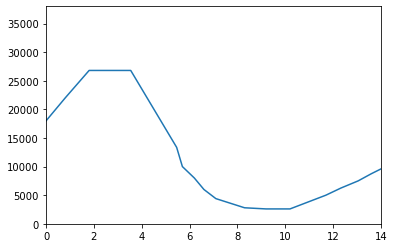

In [47]:
time = [0,100,200,300,400,500,600,700,800,1200,1600,2000,2400,2800,3200,3600,4000,4400,4800,5200,5600,6000,6400,\
       6800,7200,7600,8000,8400,8800,9200,9600,10000,10400,10800,11200,11600,12000,12400,12800,13200,13600,14000,\
        14400,14800,15200,15600,16000,16400,16800,17200,17600,18000,18400,18800,19200,19600,20000]
       
inip = [20000,17500,15000,12500,10000,8750,7500,6250,5000,2600,2600,2800,3600,4400,6000,8000,10000,13360,15040,\
        16720,18400,20080,21760,23440,25120,26800,26800,26800,26800,26800,26800,26800,26800,26800,26800,26800,\
       26800,26320,25840,25360,24880,24400,23920,23440,22960,22480,22000,21600,21200,20800,20400,20000,19600,\
        19200,18800,18400,18000]

    
# for i in [16400,16800,17200,17600,18000,18400,18800,19200,19600]:
#     inp = (18000-22000)/10 * (i-16000)/400  + 22000
#     print(inp)



xuse = [0,  0.6, 1.15,  1.87, 2.5,  4,  5,  5.9,  6.5, 7.1, 7.6,  8, 8.5,\
        8.74,8.98,9.22,9.46,9.7,9.94,10.18,10.42,10.66,  10.9,11.05, 11.2,11.35,11.5,11.65,11.8,11.95,12.1,12.25,  12.4,\
        12.5,12.6,12.7,12.8,12.9,13,13.1,13.2,13.3, 13.4,13.48,13.56,13.64,13.72,13.8,13.88,13.96,14.04,14.12 ,14.2]
yuse = inip[4:]

x = []
y = []
for i in range(len(xuse)):
    x.append(14.2 - numpy.array(xuse[len(xuse)-i-1]) )
    y.append(yuse[len(yuse)-i-1])
plt.plot(x,y)
plt.xlim(0,14,2)
plt.ylim(0,38000)


In [34]:
(14.2-13.4)/10*1 + 13.4

13.48

In [39]:
len(xuse)

56

In [44]:
7/12.4

0.564516129032258

In [45]:
4.8/8

0.6

In [46]:
1.9/5

0.38

In [1]:
import argparse
import os
import re
import numpy as np

import statistics
import msprime
from IPython.display import SVG, display
import tsinfer
import scipy
import math
import numpy
import tskit
import io
import builtins
import sys
from tqdm.notebook import tqdm
from tskit import MISSING_DATA
import pickle
import random
import matplotlib.pyplot as plt
import cvxopt as opt
from cvxopt import matrix, spmatrix, sparse
from cvxopt.solvers import qp, options
from cvxopt import blas
from cvxopt import spdiag
import statsmodels
from statsmodels.nonparametric.kernel_regression import KernelReg
from scipy.signal import savgol_filter
import time
import bisect

In [49]:
import argparse
import os
import re
import numpy as np

import statistics
import msprime
from IPython.display import SVG, display
import tsinfer
import scipy
import math
import numpy
import tskit
import io
import builtins
import sys
from tqdm.notebook import tqdm
from tskit import MISSING_DATA
import pickle
import random
import matplotlib.pyplot as plt
import cvxopt as opt
from cvxopt import matrix, spmatrix, sparse
from cvxopt.solvers import qp, options
from cvxopt import blas
from cvxopt import spdiag
import statsmodels
from statsmodels.nonparametric.kernel_regression import KernelReg
from scipy.signal import savgol_filter
import time
import bisect


def find_s(elem, sorted_list):
    'Locate the leftmost value exactly equal to x'
    i = bisect.bisect_left(sorted_list, elem)
    if i != len(sorted_list) and sorted_list[i] == elem:
        return i


def find_s_se(elem, sorted_list):
    'Locate the leftmost value smaller or equal to x'
    i = bisect.bisect_right(sorted_list, elem)
    if i != 0:
        return i-1
    else:
        print("error")


def find_s_s(elem, sorted_list):
    'Locate the leftmost value smaller or equal to x'
    i = bisect.bisect_left(sorted_list, elem)
    if i != 0:
        return i
    else:
        return 0

    
file = open("recombination_map.dat","rb")
rmap = pickle.load(file)
file.close

sam=tsinfer.load("tgp_chr20.samples")

FINlist = []
for i in range(len(sam.individuals_population)):
    if sam.individuals_population[i]==7:
        FINlist.append(i)
newdata = sam.subset(individuals=FINlist)

        
seq_len = 63025522
sam_size = 99
r = rmap
mu = 1.25*10**(-8)
# gene_conver = 10**(-8)
# track_len = 100
# epsilon = 0.0001
totaliter=1

simtime = 6
priormu = [1.0*10**(-8), 2.0*10**(-8)]
# prioreps = [0, 0.0002]
# accept_threshold = [1000,400]


demo_model = msprime.Demography.isolated_model([20000], growth_rate=[0])
demo_model.add_population_parameters_change(100,  initial_size=17500, growth_rate=0, population=None)
demo_model.add_population_parameters_change(200,  initial_size=15000, growth_rate=0, population=None)
demo_model.add_population_parameters_change(300,  initial_size=12500, growth_rate=-0, population=None)
demo_model.add_population_parameters_change(400,  initial_size=10000, growth_rate=-0, population=None)
demo_model.add_population_parameters_change(500,  initial_size=8750, growth_rate=0, population=None)
demo_model.add_population_parameters_change(600,  initial_size=7500, growth_rate=0, population=None)
demo_model.add_population_parameters_change(700,  initial_size=6250, growth_rate=0, population=None)
demo_model.add_population_parameters_change(800,  initial_size=5000, growth_rate=0.0016, population=None)
demo_model.add_population_parameters_change(1200,  initial_size=2600, growth_rate= 0, population=None)
demo_model.add_population_parameters_change(1600,  initial_size=2600, growth_rate= 0, population=None)
demo_model.add_population_parameters_change(2000,  initial_size=2800, growth_rate=-0.0006, population=None)
demo_model.add_population_parameters_change(2400,  initial_size=3600, growth_rate=-0.0005, population=None)
demo_model.add_population_parameters_change(2800,  initial_size=4400, growth_rate=-0.0007, population=None)
demo_model.add_population_parameters_change(3200,  initial_size=6000, growth_rate=-0.0007, population=None)
demo_model.add_population_parameters_change(3600,  initial_size=8000, growth_rate=-0.00055, population=None)
demo_model.add_population_parameters_change(4000,  initial_size=10000, growth_rate=-0.00024, population=None)
for i in [4400,4800,5200,5600,6000,6400,6800,7200,7600]:
    inp = (26800-10000)/10 * (i-3600)/400  + 10000
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(8000,  initial_size=26800, growth_rate=0, population=None)
for i in [8400,8800,9200,9600,10000,10400,10800,11200,11600]:
    inp = (26800-26800)/10 * (i-8000)/400  + 26800
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(12000,  initial_size=26800, growth_rate=0, population=None)
for i in [12400,12800,13200,13600,14000,14400,14800,15200,15600]:
    inp = (22000-26800)/10 * (i-12000)/400  + 26800
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(16000,  initial_size=22000, growth_rate=0, population=None)
for i in [16400,16800,17200,17600,18000,18400,18800,19200,19600]:
    inp = (18000-22000)/10 * (i-16000)/400  + 22000
    demo_model.add_population_parameters_change(i,  initial_size=inp, growth_rate=0, population=None)
demo_model.add_population_parameters_change(20000,  initial_size=18000, growth_rate=0.00005, population=None)






muhatlist = []
# epshatlist = []
muacceptlist = []
# epsacceptlist = []
for iter in range(totaliter):
    
#     ts = msprime.sim_ancestry(
#         samples=sam_size,
#         recombination_rate= r, 
#         sequence_length= seq_len,
# #         population_size = pop_size,
#         gene_conversion_rate = gene_conver ,
#         gene_conversion_tract_length = track_len,
#         #random_seed =seed,
#         #discrete_genome=False
#         demography = demo_model
#         )
#     # Visualise the simulated ancestral history.
#     #SVG(ts.draw_svg())

#     #ts.num_trees

#     mts = msprime.sim_mutations(ts, rate = mu,
#                                 #discrete_genome=False,
#                                 #random_seed=seed
#                               )

#     sample_data = tsinfer.SampleData.from_tree_sequence(mts, use_sites_time=None, use_individuals_time=None)
    
    print("done1")
        
##########################################################################################

#     newdata = tsinfer.SampleData()

#     gtypetable1 = sample_data.sites_genotypes 
#     gtypetable = gtypetable1[0:len(gtypetable1)]
#     gtypetable = gtypetable.astype("int")

#     alletable1 = sample_data.sites_alleles 
#     alletable = alletable1[0:len(alletable1)]

#     posittable1 = sample_data.sites_position 
#     posittable = posittable1[0:len(posittable1)]

#     for i in range(len(sample_data.sites_position) - 1):
#         alle = alletable[i]
#         posit = posittable[i]
#         posit1 = posittable[i+1]
#         gtype = gtypetable[i].tolist()
#         newdata.add_site(position = posit, genotypes = gtype,alleles = alle)

#         numerror = numpy.random.poisson( (posit1-posit)*2*sam_size*epsilon )
#         locerror = numpy.sort(numpy.floor(numpy.random.uniform(posit, posit1-0.000000001,numerror) )  ) .tolist()

#         curloc = posit
#         for j in range(len(locerror)):
#             if locerror[j] > curloc:
#                 curloc = locerror[j]
#                 gtype = numpy.zeros(2*sam_size  )
#                 gtype[int( numpy.random.uniform(0,2*sam_size-0.00001)   ) ] = 1
#                 gtype = gtype.astype('int').tolist()


#                 newdata.add_site(position = curloc, genotypes = gtype,alleles = ['A','T'])

#     alle = alletable[-1]
#     posit = posittable[-1]
#     gtype = gtypetable[-1].tolist()
#     newdata.add_site(position = posit, genotypes = gtype,alleles = alle)


#     newdata.finalise()



################################################################################


    inferred_ts = tsinfer.infer(newdata,path_compression=False)
    
    print("done2")

#############################################################################

    mts = inferred_ts

###############################################################################
    msites = mts.tables.mutations.site
    sitepos = mts.tables.sites.position
    mpos = []
    for i in range(len(msites)):
        cursite = msites[i]
        mpos.append(sitepos[cursite])
    mpos = numpy.array(mpos)
    mnodes = mts.tables.mutations.node
    ec = mts.tables.edges.child
    ep = mts.tables.edges.parent
    el = mts.tables.edges.left
    er = mts.tables.edges.right


    leftmost = min(el)
    rightmost = max(er)
    for i in range(len(el)):
        if el[i] == leftmost:
            el[i] = 0
        if er[i] == rightmost:
            er[i] = seq_len


    if len(mpos) == 0:
        mpos_sn = []
        mnodes_sn = []
    else:
        mnp_sn = numpy.transpose(sorted(numpy.transpose(numpy.array([mnodes,mpos])).tolist()))
        mnodes_sn = mnp_sn[0]
        mpos_sn = mnp_sn[1]

    eclrp_sc = numpy.transpose(sorted(numpy.transpose(numpy.array([ec,el,er,ep])).tolist()))
    ec_sc = eclrp_sc[0]
    el_sc = eclrp_sc[1]
    er_sc = eclrp_sc[2]
    ep_sc = eclrp_sc[3]
    enm_sc = [[] for i in range(len(ec_sc))]

    curedge = 0
    for i in range(len(mnodes_sn)):
        curnodemu = mnodes_sn[i] 
        cursitemu = mpos_sn[i]
        for j in range(curedge,len(ec_sc)):
            if curnodemu == ec_sc[j]:

                if er_sc[j] > cursitemu and el_sc[j] <= cursitemu:

                    enm_sc[j].append(cursitemu)  

                    curedge = j
                    break
                if el_sc[j] > cursitemu:
                    curedge = j
                    break

            if ec_sc[j] > mnodes_sn[i] or j == len(ec_sc)-1:
                #print("missing mutations")
                curedge = j
                break


 

    ###########################################################################
    ###########################################################################
    ##########################################################################

    clocate = []
    curc = -1
    for i in range(len(ec_sc)):
        while ec_sc[i] != curc:
            curc=curc+1
            clocate.append(i)
    clocate.append(len(ec_sc))




    abdlist = []

    for i in range(0,2*sam_size-1):
        for j in range(i+1,i+2):
            canabd = []
            curleft = 0
            curright =seq_len
            #start = 0
            while curleft != seq_len:
                curp1 = i
                curp2 = j 
                curmed = []
                while curp1 != curp2:
                    if curp1 < curp2:
                        begin1 = clocate[curp1]
                        end = clocate[curp1+1]
                        s_range = el_sc[begin1:end]
                        begin2 = find_s_se(curleft,s_range)
                        for k in range(begin1+begin2,end):
                            if el_sc[k]<=curleft and er_sc[k] > curleft:
                                curp1 = int(ep_sc[k])
                                curoldr = curright
                                curright = min(er_sc[k],curright)

                                curmed.append(k)

                                break

                    else:
                        begin1 = clocate[curp2]
                        end = clocate[curp2+1]
                        s_range = el_sc[begin1:end]
                        begin2 = find_s_se(curleft,s_range)
                        for k in range(begin1+begin2,end):
                            if el_sc[k]<=curleft and er_sc[k] > curleft:
                                curp2 = int(ep_sc[k])
                                curoldr = curright
                                curright = min(er_sc[k],curright) 

                                curmed.append(k)

                                break

                canmution = []
                for k in range(len(curmed)):
                    edgemu = enm_sc[curmed[k]]
                    startt = find_s_s(curleft,edgemu)
                    endd = find_s_s(curright,edgemu)                    
                    canmution = canmution + edgemu[startt:endd] 

                canabd.append([i,j,curleft,curright,curp1,canmution])
                curleft = curright
                curright = seq_len





            if len(canabd)==1:
                abdlist = abdlist + canabd
            else:
                curabd = [canabd[0][0],canabd[0][1],canabd[0][2],canabd[0][3],canabd[0][4],canabd[0][5]]
                for k in range(1,len(canabd)):
                    if canabd[k][4] != canabd[k-1][4]:
                        abdlist.append(curabd)
                        curabd = [canabd[k][0],canabd[k][1],canabd[k][2],canabd[k][3],canabd[k][4],canabd[k][5]]
                    else:
                        curabd[3] = canabd[k][3]
                        curabd[5] = curabd[5] + canabd[k][5]
                    if k == len(canabd)-1:
                        abdlist.append(curabd)
       
    
    
#         print("abdlist sample:",i)
        
        
        

    lllabd = len(abdlist)
    print(lllabd)
###########################################################################
###########################################################################
##########################################################################

#     #find time
#     #nt = mts.tables.nodes.time
#     nt = ts.tables.nodes.time
#     for i in range(len(abdlist)):
#         parent = int(abdlist[i][4])
#         abdlist[i].append(-1)

#         # add typing error
#         abdlist[i].append( len(abdlist[i][5])  )



###########################################################################
###########################################################################
##########################################################################

    
    abduse = abdlist



    tolnummu = 0
    for i in range(len(abduse)):
        tolnummu = tolnummu+len(abduse[i][5])

    muloclist = np.zeros(tolnummu)
    indd = 0
    for i in range(len(abduse)):
        abdc = abduse[i]
        lee = len(abdc[5])
        muloclist[indd:(indd+lee)] = abdc[5]
        indd = indd+lee

    smulist = numpy.sort(muloclist)
    count2 = 0
    curloc = -1
    curcount = 1
    for i in range(len(smulist)):
        if smulist[i] == curloc:
            curcount = curcount+1
        else:
            if curcount ==2:
                count2 = count2+1
            curcount = 1
            curloc = smulist[i]

#     summary_sta1_inf = (len(smulist) - 2*count2)/len(abduse)        
#     summary_sta2_inf = (2*count2) / len(abduse)  


    summary_sta1_inf = (len(smulist) - 2*count2)      
    summary_sta2_inf = (2*count2) 




##########################################################################
    
    muaccept = []
#     epsaccept = []
    summary_sta1_simlist=[]
    summary_sta2_simlist=[]
    stime = time.time()

    for run in range(simtime):
        
#         musim = numpy.random.uniform(priormu[0],priormu[1])
        if run == 0:
            musim = 1.3*10**(-8)
        if run == 1:
            musim = 1.3*10**(-8)
        if run == 2:
            musim = 1.6*10**(-8)
        if run == 3:
            musim = 1.6*10**(-8)
        if run == 4:
            musim = 2*10**(-8)
        if run == 5:
            musim = 2*10**(-8)            
            
            
#         epssim = numpy.random.uniform(prioreps[0],prioreps[1])
        print("done1")
 
        ts = msprime.sim_ancestry(
            samples=sam_size,
            recombination_rate= r, 
            sequence_length= seq_len,
            record_provenance=False,
#             population_size = pop_size,
#             gene_conversion_rate = gene_conver ,
#             gene_conversion_tract_length = track_len,
            #random_seed =seed,
            #discrete_genome=False
            demography = demo_model
            )
        # Visualise the simulated ancestral history.
        #SVG(ts.draw_svg())

        #ts.num_trees
        
        print("done gene")

        mts = msprime.sim_mutations(ts, rate = musim,
                                    #discrete_genome=False,
                                    #random_seed=seed
                                  )

        print("done mu")

        sample_data = tsinfer.SampleData.from_tree_sequence(mts, use_sites_time=None, use_individuals_time=None)


        print("done sam")
##########################################################################################

#         newdata = tsinfer.SampleData()

#         gtypetable1 = sample_data.sites_genotypes 
#         gtypetable = gtypetable1[0:len(gtypetable1)]
#         gtypetable = gtypetable.astype("int")

#         alletable1 = sample_data.sites_alleles 
#         alletable = alletable1[0:len(alletable1)]

#         posittable1 = sample_data.sites_position 
#         posittable = posittable1[0:len(posittable1)]

#         for i in range(len(sample_data.sites_position) - 1):
#             alle = alletable[i]
#             posit = posittable[i]
#             posit1 = posittable[i+1]
#             gtype = gtypetable[i].tolist()
#             newdata.add_site(position = posit, genotypes = gtype,alleles = alle)

#             numerror = numpy.random.poisson( (posit1-posit)*2*sam_size*epssim )
#             locerror = numpy.sort(numpy.floor(numpy.random.uniform(posit, posit1-0.000000001,numerror) )  ) .tolist()

#             curloc = posit
#             for j in range(len(locerror)):
#                 if locerror[j] > curloc:
#                     curloc = locerror[j]
#                     gtype = numpy.zeros(2*sam_size  )
#                     gtype[int( numpy.random.uniform(0,2*sam_size-0.00001)   ) ] = 1
#                     gtype = gtype.astype('int').tolist()


#                     newdata.add_site(position = curloc, genotypes = gtype,alleles = ['A','T'])

#         alle = alletable[-1]
#         posit = posittable[-1]
#         gtype = gtypetable[-1].tolist()
#         newdata.add_site(position = posit, genotypes = gtype,alleles = alle)


#         newdata.finalise()

        
################################################################################


        inferred_ts = tsinfer.infer(sample_data,path_compression=False)

        print("iter",run,"done2")
        
        
#############################################################################

        mts = inferred_ts

###############################################################################

        msites = mts.tables.mutations.site
        sitepos = mts.tables.sites.position
        mpos = []
        for i in range(len(msites)):
            cursite = msites[i]
            mpos.append(sitepos[cursite])
        mpos = numpy.array(mpos)
        mnodes = mts.tables.mutations.node
        ec = mts.tables.edges.child
        ep = mts.tables.edges.parent
        el = mts.tables.edges.left
        er = mts.tables.edges.right


        leftmost = min(el)
        rightmost = max(er)
        for i in range(len(el)):
            if el[i] == leftmost:
                el[i] = 0
            if er[i] == rightmost:
                er[i] = seq_len


        if len(mpos) == 0:
            mpos_sn = []
            mnodes_sn = []
        else:
            mnp_sn = numpy.transpose(sorted(numpy.transpose(numpy.array([mnodes,mpos])).tolist()))
            mnodes_sn = mnp_sn[0]
            mpos_sn = mnp_sn[1]

        eclrp_sc = numpy.transpose(sorted(numpy.transpose(numpy.array([ec,el,er,ep])).tolist()))
        ec_sc = eclrp_sc[0]
        el_sc = eclrp_sc[1]
        er_sc = eclrp_sc[2]
        ep_sc = eclrp_sc[3]
        enm_sc = [[] for i in range(len(ec_sc))]

        curedge = 0
        for i in range(len(mnodes_sn)):
            curnodemu = mnodes_sn[i] 
            cursitemu = mpos_sn[i]
            for j in range(curedge,len(ec_sc)):
                if curnodemu == ec_sc[j]:

                    if er_sc[j] > cursitemu and el_sc[j] <= cursitemu:

                        enm_sc[j].append(cursitemu)  

                        curedge = j
                        break
                    if el_sc[j] > cursitemu:
                        curedge = j
                        break

                if ec_sc[j] > mnodes_sn[i] or j == len(ec_sc)-1:
                    #print("missing mutations")
                    curedge = j
                    break




        ###########################################################################
        ###########################################################################
        ##########################################################################

        clocate = []
        curc = -1
        for i in range(len(ec_sc)):
            while ec_sc[i] != curc:
                curc=curc+1
                clocate.append(i)
        clocate.append(len(ec_sc))




        abdlist = []

        for i in range(0,2*sam_size-1):
            for j in range(i+1,i+2):
                canabd = []
                curleft = 0
                curright =seq_len
                #start = 0
                while curleft != seq_len:
                    curp1 = i
                    curp2 = j 
                    curmed = []
                    while curp1 != curp2:
                        if curp1 < curp2:
                            begin1 = clocate[curp1]
                            end = clocate[curp1+1]
                            s_range = el_sc[begin1:end]
                            begin2 = find_s_se(curleft,s_range)
                            for k in range(begin1+begin2,end):
                                if el_sc[k]<=curleft and er_sc[k] > curleft:
                                    curp1 = int(ep_sc[k])
                                    curoldr = curright
                                    curright = min(er_sc[k],curright)

                                    curmed.append(k)

                                    break

                        else:
                            begin1 = clocate[curp2]
                            end = clocate[curp2+1]
                            s_range = el_sc[begin1:end]
                            begin2 = find_s_se(curleft,s_range)
                            for k in range(begin1+begin2,end):
                                if el_sc[k]<=curleft and er_sc[k] > curleft:
                                    curp2 = int(ep_sc[k])
                                    curoldr = curright
                                    curright = min(er_sc[k],curright) 

                                    curmed.append(k)

                                    break

                    canmution = []
                    for k in range(len(curmed)):
                        edgemu = enm_sc[curmed[k]]
                        startt = find_s_s(curleft,edgemu)
                        endd = find_s_s(curright,edgemu)                    
                        canmution = canmution + edgemu[startt:endd] 

                    canabd.append([i,j,curleft,curright,curp1,canmution])
                    curleft = curright
                    curright = seq_len





                if len(canabd)==1:
                    abdlist = abdlist + canabd
                else:
                    curabd = [canabd[0][0],canabd[0][1],canabd[0][2],canabd[0][3],canabd[0][4],canabd[0][5]]
                    for k in range(1,len(canabd)):
                        if canabd[k][4] != canabd[k-1][4]:
                            abdlist.append(curabd)
                            curabd = [canabd[k][0],canabd[k][1],canabd[k][2],canabd[k][3],canabd[k][4],canabd[k][5]]
                        else:
                            curabd[3] = canabd[k][3]
                            curabd[5] = curabd[5] + canabd[k][5]
                        if k == len(canabd)-1:
                            abdlist.append(curabd)

#             print("iter:",run, "abdlist sample:",i)

    ###########################################################################
    ###########################################################################
    ##########################################################################

#         #find time
#         #nt = mts.tables.nodes.time
#         nt = ts.tables.nodes.time
#         for i in range(len(abdlist)):
#             parent = int(abdlist[i][4])
#             abdlist[i].append(-1)

#             # total typing error
#             abdlist[i].append( len(abdlist[i][5])  )
            



    ###########################################################################
    ###########################################################################
    ##########################################################################


        abduse = abdlist



        tolnummu = 0
        for i in range(len(abduse)):
            tolnummu = tolnummu+len(abduse[i][5])


        muloclist = np.zeros(tolnummu)
        indd = 0
        for i in range(len(abduse)):
            abdc = abduse[i]
            lee = len(abdc[5])
            muloclist[indd:(indd+lee)] = abdc[5]
            indd = indd+lee
            
        smulist = numpy.sort(muloclist)
        count2 = 0
        curloc = -1
        curcount = 1
        for i in range(len(smulist)):
            if smulist[i] == curloc:
                curcount = curcount+1
            else:
                if curcount ==2:
                    count2 = count2+1
                curcount = 1
                curloc = smulist[i]
        
#         summary_sta1_sim = (len(smulist) - 2*count2)/len(abduse)        
#         summary_sta2_sim = (2*count2) / len(abduse)

        summary_sta1_sim = (len(smulist) - 2*count2)        
        summary_sta2_sim = (2*count2)  

        summary_sta1_simlist.append(summary_sta1_sim)
        summary_sta2_simlist.append(summary_sta2_sim)
#         
#         if abs(summary_sta1_sim - summary_sta1_inf) < accept_threshold[0] and abs(summary_sta2_sim - summary_sta2_inf) < accept_threshold[1]:
        muaccept.append(musim)
#         epsaccept.append(epssim)

            
        etime = time.time()

            
        print("run",run,etime-stime)
        
   
        
        
    muacceptlist = muacceptlist + muaccept
#     epsacceptlist= epsacceptlist + epsaccept
    
    
#     if len(muaccept)>0:    
#         muhatlist.append(statistics.mean(muaccept))
#     else:
#         muhatlist.append(None)    
        
#     if len(epsaccept)>0:    
#         epshatlist.append(statistics.mean(epsaccept))
#     else:
#         epshatlist.append(None)  
    
#     print(muhatlist)


done1
done2
1453027
done1
done gene
done mu
done sam
iter 0 done2
run 0 404.1773018836975
done1
done gene
done mu
done sam
iter 1 done2
run 1 841.0106949806213
done1
done gene
done mu
done sam
iter 2 done2
run 2 1371.6782591342926
done1
done gene
done mu
done sam
iter 3 done2
run 3 1887.0098857879639
done1
done gene
done mu
done sam
iter 4 done2
run 4 2547.5059707164764
done1
done gene
done mu
done sam
iter 5 done2
run 5 3177.115290403366


In [50]:
summary_sta1_simlist

[6002106, 5993014, 7379638, 7528210, 9451621, 9213757]

In [51]:
summary_sta1_inf

7893005

In [52]:
summary_sta2_simlist

[82260, 80304, 97984, 99464, 119734, 125352]

In [53]:
summary_sta2_inf

78262

In [54]:
10**(-5)/2.6/10**(-8)

384.6153846153846

In [55]:
384*25

9600

In [56]:
4*1.3

5.2

In [57]:
1/5.2*5

0.9615384615384615

In [58]:
1/400*384.6153846153846

0.9615384615384615

In [59]:
numpy.log(268/220)/4000

4.9339858539623796e-05